# Task 02 – Build and Compare Machine Learning Models
**Problem:** House Price Prediction (Regression) | **Dataset:** enhanced_house_price_dataset.csv (2000 records, 16 columns)

## Part 1 – Data Preprocessing

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

### 1.1 Load the dataset

In [2]:
df = pd.read_csv("enhanced_house_price_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (2000, 16)


,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Area              2000 non-null   int64
 1   Bedrooms          2000 non-null   int64
 2   Bathrooms         2000 non-null   int64
 3   Stories           2000 non-null   int64
 4   Parking           2000 non-null   int64
 5   Age               2000 non-null   int64
 6   City              2000 non-null   str  
 7   Furnishing        2000 non-null   str  
 8   Main Road         2000 non-null   str  
 9   Guest Room        2000 non-null   str  
 10  Basement          2000 non-null   str  
 11  Water Supply      2000 non-null   str  
 12  Air Conditioning  2000 non-null   str  
 13  Preferred Tenant  2000 non-null   str  
 14  Locality Rating   2000 non-null   int64
 15  Price             2000 non-null   int64
dtypes: int64(8), str(8)
memory usage: 250.1 KB


In [4]:
df.describe()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,3238.081000,3.031000,2.02150,1.996000,0.990500,24.008500,5.357500,1.245014e+06
std,1604.510239,1.427255,0.81263,0.811981,0.806682,14.319076,2.843015,3.001744e+05
min,401.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.000000,3.346350e+05
25%,1860.000000,2.000000,1.00000,1.000000,0.000000,12.000000,3.000000,1.035278e+06
50%,3271.500000,3.000000,2.00000,2.000000,1.000000,24.000000,5.000000,1.246602e+06
75%,4599.750000,4.000000,3.00000,3.000000,2.000000,36.000000,8.000000,1.453607e+06
max,5996.000000,5.000000,3.00000,3.000000,2.000000,49.000000,10.000000,2.225409e+06


### 1.2 Handle missing values

In [5]:
print(df.isnull().sum())

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())      # numeric -> median

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])     # categorical -> mode

print("\nMissing values after handling:", int(df.isnull().sum().sum()))

Area                0
Bedrooms            0
Bathrooms           0
Stories             0
Parking             0
Age                 0
City                0
Furnishing          0
Main Road           0
Guest Room          0
Basement            0
Water Supply        0
Air Conditioning    0
Preferred Tenant    0
Locality Rating     0
Price               0
dtype: int64

Missing values after handling: 0


### 1.3 Remove duplicates

In [6]:
print("Duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after :", df.duplicated().sum())
print("Final shape          :", df.shape)

Duplicate rows before: 0
Duplicate rows after : 0
Final shape          : (2000, 16)


### 1.4 Exploratory Data Analysis

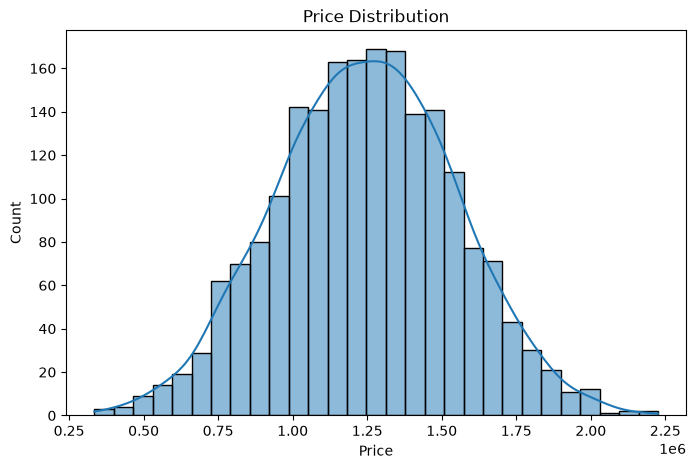

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution")
plt.show()

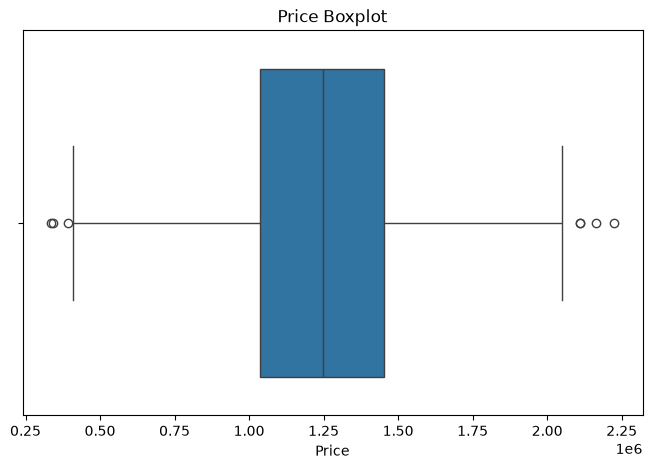

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Price"])
plt.title("Price Boxplot")
plt.show()

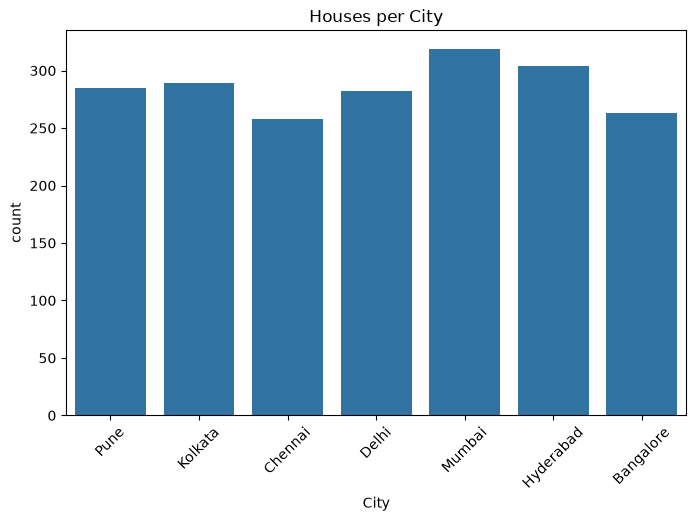

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["City"])
plt.xticks(rotation=45)
plt.title("Houses per City")
plt.show()

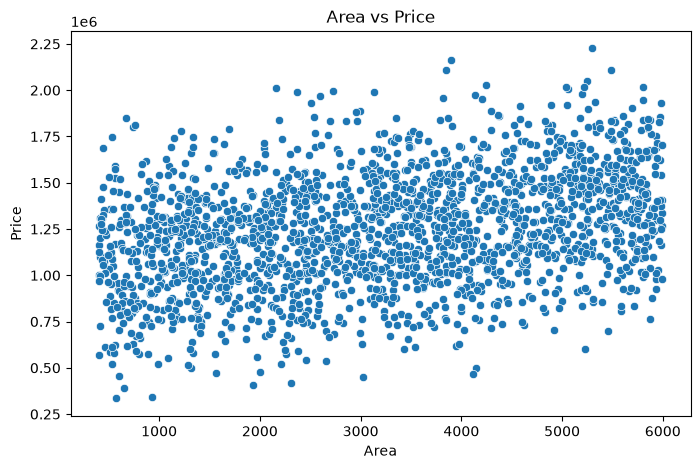

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Area", y="Price", data=df)
plt.title("Area vs Price")
plt.show()

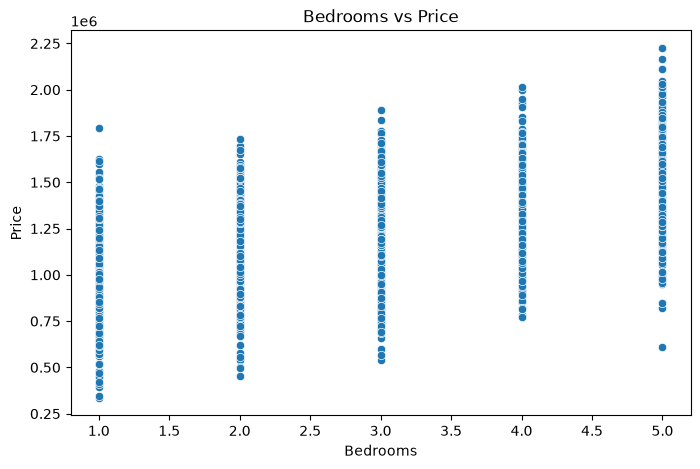

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Bedrooms", y="Price", data=df)
plt.title("Bedrooms vs Price")
plt.show()

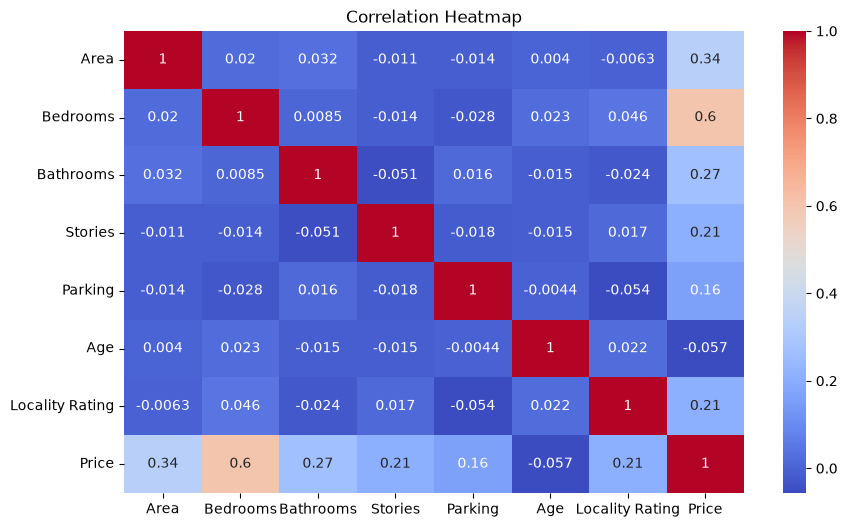

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### 1.5 Encode categorical features, scale numerical features, train/test split

In [13]:
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (1600, 15) | Test: (400, 15)


In [15]:
numeric_features = ['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'Locality Rating']

categorical_features = ['City', 'Furnishing', 'Main Road', 'Guest Room',
                        'Basement', 'Water Supply', 'Air Conditioning', 'Preferred Tenant']

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),                              # scaling
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)     # encoding
    ]
)

## Part 2 – Model Development
Five regression models are trained: Linear Regression, Decision Tree, Random Forest, KNN and SVM (SVR).

*Note:* Logistic Regression and the classification metrics (Accuracy, Precision, Recall, F1, Confusion Matrix) apply to
classification problems only. House price prediction is a **regression** problem, so MAE, MSE, RMSE and R² are used instead.

For SVR the target (`Price`) is also scaled (`TransformedTargetRegressor`). Without this, SVR performs very poorly
because Price is in the range of lakhs/millions.

In [17]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "SVM (SVR)": TransformedTargetRegressor(
        regressor=SVR(kernel="rbf", C=10),
        transformer=StandardScaler()
    ),
}

fitted = {}
records = []

for name, reg in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", reg)])

    start = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start

    pred = pipe.predict(X_test)
    mse = mean_squared_error(y_test, pred)

    fitted[name] = pipe
    records.append({
        "Model": name,
        "Training Time (s)": round(train_time, 4),
        "MAE": mean_absolute_error(y_test, pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_test, pred),
    })
    print(f"{name:<18} done | R2 = {records[-1]['R2']:.4f}")

Linear Regression  done | R2 = 0.7779
Decision Tree      done | R2 = 0.2837
Random Forest      done | R2 = 0.6764
KNN                done | R2 = 0.6050
SVM (SVR)          done | R2 = 0.6367


## Part 3 – Model Evaluation

In [19]:
results = pd.DataFrame(records)
results.sort_values("R2", ascending=False).reset_index(drop=True)

,Model,Training Time (s),MAE,MSE,RMSE,R2
0,Linear Regression,0.1001,111763.710469,2.013303e+10,141890.918385,0.777884
1,Random Forest,1.9971,137591.953875,2.933264e+10,171267.742494,0.676390
2,SVM (SVR),1.1559,145993.078390,3.293230e+10,181472.599459,0.636677
3,KNN,0.0350,154169.326500,3.580616e+10,189225.163244,0.604972
4,Decision Tree,0.0978,207370.070000,6.492937e+10,254812.429565,0.283672


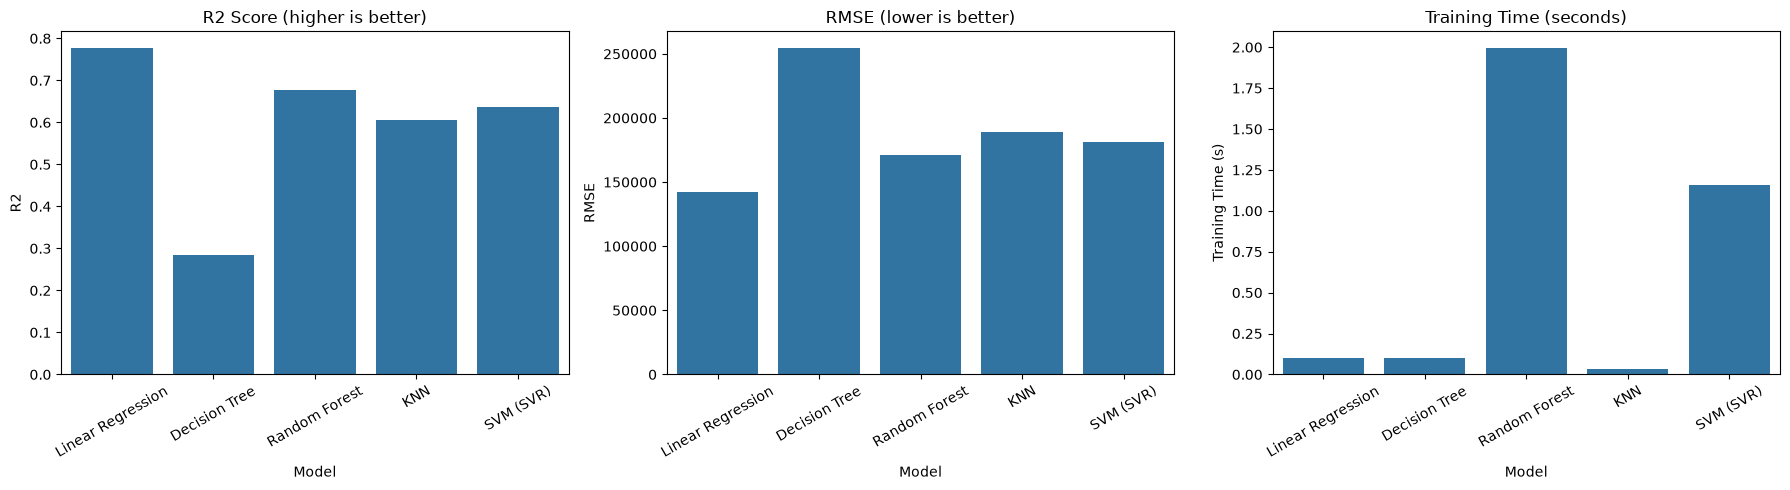

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x="Model", y="R2", data=results, ax=axes[0])
axes[0].set_title("R2 Score (higher is better)")

sns.barplot(x="Model", y="RMSE", data=results, ax=axes[1])
axes[1].set_title("RMSE (lower is better)")

sns.barplot(x="Model", y="Training Time (s)", data=results, ax=axes[2])
axes[2].set_title("Training Time (seconds)")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

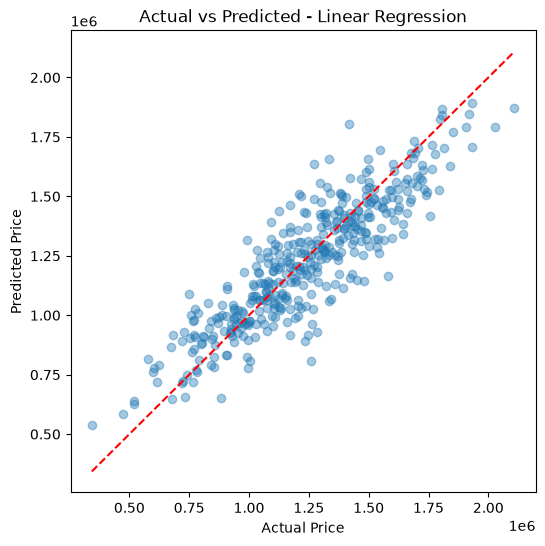

In [21]:
best_name = results.sort_values("R2", ascending=False).iloc[0]["Model"]
best_pred = fitted[best_name].predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_pred, alpha=0.4)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted - {best_name}")
plt.show()

## Part 4 – Model Comparison

In [22]:
advantages = {
    "Linear Regression": "Very fast, simple, easy to interpret; works very well when the relationship is roughly linear.",
    "Decision Tree": "Easy to understand and visualise; captures non-linear relationships; needs little preprocessing.",
    "Random Forest": "Handles non-linear patterns and interactions; more stable and less overfitting than a single tree.",
    "KNN": "Simple, no training phase, makes no assumption about the data.",
    "SVM (SVR)": "Can model non-linear relationships (RBF kernel); robust in high-dimensional data.",
}
limitations = {
    "Linear Regression": "Cannot capture complex non-linear relationships; sensitive to outliers.",
    "Decision Tree": "Overfits easily and is unstable (high variance).",
    "Random Forest": "Slower to train and predict; less interpretable than a single model.",
    "KNN": "Slow at prediction time; sensitive to feature scaling and irrelevant features.",
    "SVM (SVR)": "Slow on large datasets; sensitive to hyperparameters (C, gamma) and needs scaling.",
}

comparison = results.copy()
comparison["Advantages"] = comparison["Model"].map(advantages)
comparison["Limitations"] = comparison["Model"].map(limitations)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 250)
comparison[["Model", "Training Time (s)", "MAE", "MSE", "RMSE", "R2", "Advantages", "Limitations"]]

,Model,Training Time (s),MAE,MSE,RMSE,R2,Advantages,Limitations
0,Linear Regression,0.1001,111763.710469,2.013303e+10,141890.918385,0.777884,"Very fast, simple, easy to interpret; works very well when the relationship is roughly linear.",Cannot capture complex non-linear relationships; sensitive to outliers.
1,Decision Tree,0.0978,207370.070000,6.492937e+10,254812.429565,0.283672,Easy to understand and visualise; captures non-linear relationships; needs little preprocessing.,Overfits easily and is unstable (high variance).
2,Random Forest,1.9971,137591.953875,2.933264e+10,171267.742494,0.676390,Handles non-linear patterns and interactions; more stable and less overfitting than a single tree.,Slower to train and predict; less interpretable than a single model.
3,KNN,0.0350,154169.326500,3.580616e+10,189225.163244,0.604972,"Simple, no training phase, makes no assumption about the data.",Slow at prediction time; sensitive to feature scaling and irrelevant features.
4,SVM (SVR),1.1559,145993.078390,3.293230e+10,181472.599459,0.636677,Can model non-linear relationships (RBF kernel); robust in high-dimensional data.,"Slow on large datasets; sensitive to hyperparameters (C, gamma) and needs scaling."


## Bonus – Hyperparameter Tuning (GridSearchCV)

In [23]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5],
}

grid = GridSearchCV(rf_pipe, param_grid, cv=3, scoring="r2", n_jobs=-1)

start = time.time()
grid.fit(X_train, y_train)
tune_time = time.time() - start

print("Best parameters :", grid.best_params_)
print("Best CV R2      :", round(grid.best_score_, 4))
print("Tuning time (s) :", round(tune_time, 2))

Best parameters : {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 150}
Best CV R2      : 0.6264
Tuning time (s) : 26.67


In [24]:
tuned = grid.best_estimator_
tuned_pred = tuned.predict(X_test)
tuned_mse = mean_squared_error(y_test, tuned_pred)

tuned_row = {
    "Model": "Random Forest (Tuned)",
    "Training Time (s)": round(tune_time, 4),
    "MAE": mean_absolute_error(y_test, tuned_pred),
    "MSE": tuned_mse,
    "RMSE": np.sqrt(tuned_mse),
    "R2": r2_score(y_test, tuned_pred),
}

final_results = pd.concat([results, pd.DataFrame([tuned_row])], ignore_index=True)
final_results = final_results.sort_values("R2", ascending=False).reset_index(drop=True)
final_results

,Model,Training Time (s),MAE,MSE,RMSE,R2
0,Linear Regression,0.1001,111763.710469,2.013303e+10,141890.918385,0.777884
1,Random Forest (Tuned),26.6702,137376.977044,2.909924e+10,170585.000485,0.678965
2,Random Forest,1.9971,137591.953875,2.933264e+10,171267.742494,0.676390
3,SVM (SVR),1.1559,145993.078390,3.293230e+10,181472.599459,0.636677
4,KNN,0.0350,154169.326500,3.580616e+10,189225.163244,0.604972
5,Decision Tree,0.0978,207370.070000,6.492937e+10,254812.429565,0.283672


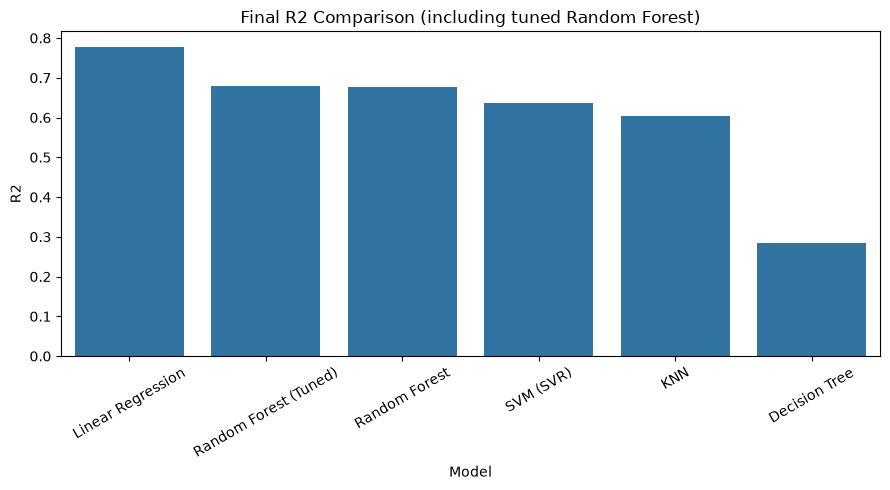

In [25]:
plt.figure(figsize=(9,5))
sns.barplot(x="Model", y="R2", data=final_results)
plt.xticks(rotation=30)
plt.title("Final R2 Comparison (including tuned Random Forest)")
plt.tight_layout()
plt.show()

final_results.to_csv("model_comparison_results.csv", index=False)

## Part 5 – Conclusion

In [26]:
why = {
    "Linear Regression": "the price in this dataset depends mostly on features in an (almost) linear way, so a simple linear model fits it well, generalises well and does not overfit.",
    "Random Forest": "it combines many trees, so it captures non-linear patterns and interactions between features while overfitting less than a single tree.",
    "Random Forest (Tuned)": "hyperparameter tuning found a better balance between model complexity and generalisation for the Random Forest.",
    "KNN": "it uses the similarity between houses, which works reasonably but suffers from many one-hot encoded features.",
    "Decision Tree": "it captures non-linear splits, but a single deep tree overfits the training data.",
    "SVM (SVR)": "it can model non-linear patterns when its parameters are tuned properly.",
}

top = final_results.iloc[0]
worst = final_results.iloc[-1]

print("BEST MODEL:", top["Model"])
print(f"  R2   = {top['R2']:.4f}")
print(f"  MAE  = {top['MAE']:,.0f}")
print(f"  RMSE = {top['RMSE']:,.0f}")
print(f"  Training time = {top['Training Time (s)']} s")
print("\nWhy it performed best:", why.get(top["Model"], ""))
print(f"\nLowest performing model: {worst['Model']} (R2 = {worst['R2']:.4f})")

BEST MODEL: Linear Regression
  R2   = 0.7779
  MAE  = 111,764
  RMSE = 141,891
  Training time = 0.1001 s

Why it performed best: the price in this dataset depends mostly on features in an (almost) linear way, so a simple linear model fits it well, generalises well and does not overfit.

Lowest performing model: Decision Tree (R2 = 0.2837)


**Conclusion.** The model with the highest R² and the lowest MAE/RMSE on the test set (printed above) is recommended for
house price prediction on this dataset. Model selection was based on test-set R², MAE and RMSE, and training time was
also considered. Random Forest was further improved with GridSearchCV.